## 1. Finish EDA

In [69]:
!pip install langdetect spacy underthesea deep_translator vaderSentiment wordcloud

In [70]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import wordcloud
import seaborn as sns
import langdetect
from langdetect import detect, DetectorFactory
import spacy # Handle english text
import nltk

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
#Importing dataset and take a look at the first 5 rows
reddit_employ = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/reddit_employment_master.csv")
reddit_employ.head()

,subreddit,title,selftext,author,score,num_comments,created_utc,url
0,VietNam,How to cook authentic Hanoi style Pho Ga with clean broth,"https://preview.redd.it/1ry0labugyig1.png?width=650&amp;format=png&amp;auto=webp&amp;s=9fae680bd17ffd802cad36e8fadcce09aa6a7101\n\n\n\n \nI wanna cook pho ga that looks like this that has clean broth, not dark brown or cloudy broth.\n\n \nI tried today using star anise, fennel seeds, cinnamon sticks, cloves + Japanese MSG but no fish sauce and it turned out to be thick brown that tastes like HCM style pho to me.\n\n \nI boiled chicken meat (Not the whole chicken but pieces including chicken thighs, legs and breasts) for like 40-50mins as well.\n\n \nCan somebody tell me how I can cook like above photo? \n\nI followed one Hanoi Pho Ga recipe recipe online and it tastes like typical Pho I had in HCMC.",Important_Back_7132,1,0,2026-02-11 19:12:42,https://www.reddit.com/r/VietNam/comments/1r2ecng/how_to_cook_authentic_hanoi_style_pho_ga_with/
1,VietNam,Getting Levothyroxine for thyroid in Vietnam -- any problems obtaining it without a prescription?,NaN,FrancoisMauriac,1,0,2026-02-11 19:05:56,https://www.reddit.com/r/VietNam/comments/1r2e6zv/getting_levothyroxine_for_thyroid_in_vietnam_any/
2,VietNam,"Moc Chau, Ta Xua, Ha Giang, Sapa - Which is the least favourite one?","Hello,\n\nfor planning a first trip to North Vietnam as a tourist I am in Hanoi for around two weeks. My plan would be as following:\n\n01.05 - 03.05 Moc Chau\n\n03.05 - 05.05 Ta Xua\n\n05.05 - 06.05 Hanoi (seems like there is no direct way from Ta Xua to Ha Giang)\n\n06.05 - 07.05 Ha Giang\n\n08.05 - 11.05 Sapa\n\n \nDoes the amount of spending days make sense? I am a little afraid of the long bus travels between those locations. And if you were to advise against one place, which one would it be? Not sure if I can meet all those places on time. PS.: I am not a motorcycle driver.",Firehead1971,1,3,2026-02-11 18:38:28,https://www.reddit.com/r/VietNam/comments/1r2dj6j/moc_chau_ta_xua_ha_giang_sapa_which_is_the_least/
3,VietNam,bug bite help,"Hi, I’ve had this bug bite for over a week and it keeps getting larger despite topical medicine from the pharmacy. The yellowish ring is one of the medicines they gave me. It is incredibly itchy. It hasn’t gotten better after over three days of the medicine, does anyone know what it could be/is it cause for concern/should I go to a doctor? It’s about the size of a quarter. I am in central Vietnam. I also have a sore throat but am not sure if they are related. I have no other symptoms. Thank you for any help 🙇‍♀️♥️",lilpress13,6,32,2026-02-11 18:11:06,https://i.redd.it/k0jayy3l6yig1.jpeg
4,VietNam,My friend just lost her mom,"Hi, \n\nMy good friend and coworker lost her mom earlier this week. My friend is originally from Vietnam and I would like to show respect and sympathy. My coworkers and I are pulling money together to get a gift for her. I was wondering if there is anything special or traditional that we can do for her. We are in the states and typically have a card that everyone signs and flowers. Is there anything else I can do for her? \n\nThank you in advance.",MeowMeow_77,6,4,2026-02-11 16:00:16,https://www.reddit.com/r/VietNam/comments/1r29gog/my_friend_just_lost_her_mom/


In [73]:
# Review number of entries and columns
reddit_employ.shape

(2800, 8)

In [74]:
# Created a copy of the reddit_employ dataset
pd.set_option("display.max_colwidth", None) # Take a peak at the whole text to see the usual pattern of a thread
reddit_df = reddit_employ.copy()
reddit_df.head(3)

,subreddit,title,selftext,author,score,num_comments,created_utc,url
0,VietNam,How to cook authentic Hanoi style Pho Ga with clean broth,"https://preview.redd.it/1ry0labugyig1.png?width=650&amp;format=png&amp;auto=webp&amp;s=9fae680bd17ffd802cad36e8fadcce09aa6a7101\n\n\n\n \nI wanna cook pho ga that looks like this that has clean broth, not dark brown or cloudy broth.\n\n \nI tried today using star anise, fennel seeds, cinnamon sticks, cloves + Japanese MSG but no fish sauce and it turned out to be thick brown that tastes like HCM style pho to me.\n\n \nI boiled chicken meat (Not the whole chicken but pieces including chicken thighs, legs and breasts) for like 40-50mins as well.\n\n \nCan somebody tell me how I can cook like above photo? \n\nI followed one Hanoi Pho Ga recipe recipe online and it tastes like typical Pho I had in HCMC.",Important_Back_7132,1,0,2026-02-11 19:12:42,https://www.reddit.com/r/VietNam/comments/1r2ecng/how_to_cook_authentic_hanoi_style_pho_ga_with/
1,VietNam,Getting Levothyroxine for thyroid in Vietnam -- any problems obtaining it without a prescription?,NaN,FrancoisMauriac,1,0,2026-02-11 19:05:56,https://www.reddit.com/r/VietNam/comments/1r2e6zv/getting_levothyroxine_for_thyroid_in_vietnam_any/
2,VietNam,"Moc Chau, Ta Xua, Ha Giang, Sapa - Which is the least favourite one?","Hello,\n\nfor planning a first trip to North Vietnam as a tourist I am in Hanoi for around two weeks. My plan would be as following:\n\n01.05 - 03.05 Moc Chau\n\n03.05 - 05.05 Ta Xua\n\n05.05 - 06.05 Hanoi (seems like there is no direct way from Ta Xua to Ha Giang)\n\n06.05 - 07.05 Ha Giang\n\n08.05 - 11.05 Sapa\n\n \nDoes the amount of spending days make sense? I am a little afraid of the long bus travels between those locations. And if you were to advise against one place, which one would it be? Not sure if I can meet all those places on time. PS.: I am not a motorcycle driver.",Firehead1971,1,3,2026-02-11 18:38:28,https://www.reddit.com/r/VietNam/comments/1r2dj6j/moc_chau_ta_xua_ha_giang_sapa_which_is_the_least/


Since we intentionally scrape 200 topics from each subreddits, we can expect a pretty balanced distribution among the subreddits

## Data Cleaning and Preprocessing

In [75]:
# Checking for any null values
reddit_df.isnull().sum()

,0
subreddit,0
title,0
selftext,449
author,0
score,0
num_comments,0
created_utc,0
url,0


There're approximately 449 text that are null in the `selftext` column, let's fill null values with blank spaces first for NLP purpose later.

In [76]:
# Fill `selftext` column with "" first
reddit_df['selftext'] = reddit_df['selftext'].fillna("")
print(reddit_df.isnull().sum())

subreddit       0
title           0
selftext        0
author          0
score           0
num_comments    0
created_utc     0
url             0
dtype: int64


In [77]:
# Combine `title` & `selftext` columns together since titles contain the main ideas, selftext contains details => more convenients when doing EDA later
reddit_df['full_text'] = reddit_df['title'] + " " + reddit_df["selftext"]
# check the full_text column
reddit_df['full_text'].head()

,full_text
0,"How to cook authentic Hanoi style Pho Ga with clean broth https://preview.redd.it/1ry0labugyig1.png?width=650&amp;format=png&amp;auto=webp&amp;s=9fae680bd17ffd802cad36e8fadcce09aa6a7101\n\n\n\n \nI wanna cook pho ga that looks like this that has clean broth, not dark brown or cloudy broth.\n\n \nI tried today using star anise, fennel seeds, cinnamon sticks, cloves + Japanese MSG but no fish sauce and it turned out to be thick brown that tastes like HCM style pho to me.\n\n \nI boiled chicken meat (Not the whole chicken but pieces including chicken thighs, legs and breasts) for like 40-50mins as well.\n\n \nCan somebody tell me how I can cook like above photo? \n\nI followed one Hanoi Pho Ga recipe recipe online and it tastes like typical Pho I had in HCMC."
1,Getting Levothyroxine for thyroid in Vietnam -- any problems obtaining it without a prescription?
2,"Moc Chau, Ta Xua, Ha Giang, Sapa - Which is the least favourite one? Hello,\n\nfor planning a first trip to North Vietnam as a tourist I am in Hanoi for around two weeks. My plan would be as following:\n\n01.05 - 03.05 Moc Chau\n\n03.05 - 05.05 Ta Xua\n\n05.05 - 06.05 Hanoi (seems like there is no direct way from Ta Xua to Ha Giang)\n\n06.05 - 07.05 Ha Giang\n\n08.05 - 11.05 Sapa\n\n \nDoes the amount of spending days make sense? I am a little afraid of the long bus travels between those locations. And if you were to advise against one place, which one would it be? Not sure if I can meet all those places on time. PS.: I am not a motorcycle driver."
3,"bug bite help Hi, I’ve had this bug bite for over a week and it keeps getting larger despite topical medicine from the pharmacy. The yellowish ring is one of the medicines they gave me. It is incredibly itchy. It hasn’t gotten better after over three days of the medicine, does anyone know what it could be/is it cause for concern/should I go to a doctor? It’s about the size of a quarter. I am in central Vietnam. I also have a sore throat but am not sure if they are related. I have no other symptoms. Thank you for any help 🙇‍♀️♥️"
4,"My friend just lost her mom Hi, \n\nMy good friend and coworker lost her mom earlier this week. My friend is originally from Vietnam and I would like to show respect and sympathy. My coworkers and I are pulling money together to get a gift for her. I was wondering if there is anything special or traditional that we can do for her. We are in the states and typically have a card that everyone signs and flowers. Is there anything else I can do for her? \n\nThank you in advance."


Since we intentionally scrape 200 topics from each subreddits, we can expect a pretty balanced distribution among the subreddits

/tmp/ipykernel_280/4017411493.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




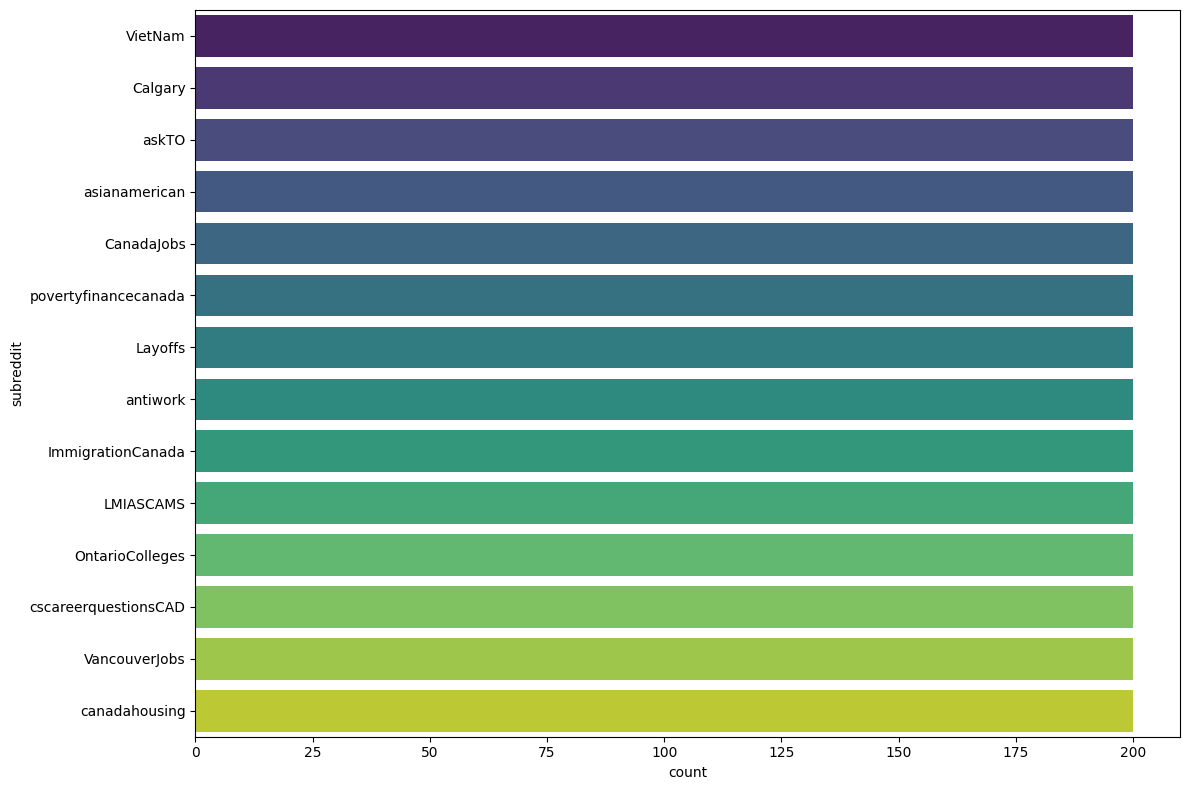

In [78]:
# Count how many texts are there in each subreddits
subreddit_counts = reddit_df['subreddit'].value_counts().reset_index()
subreddit_counts.columns = ['subreddit', 'count']

plt.figure(figsize =(12, 8))
sns.barplot(data = subreddit_counts,
            x = 'count', y = 'subreddit',
            palette = 'viridis')

plt.tight_layout()
plt.savefig('subreddit_counts.png')
plt.show()

The subreddits are mostly in English, the rest are other languages (including Vietnamese). Since our concerns in this project is about Vietnamese and English, we'll sort out other languages (e.g. French, Japanese, etc.)

## 1. b. Language detection (we'll focus on Vietnamese and English in this project)
- Devide the datasets into two: `english_df` and `vietnamese_df`, for those text that contains both english and vietnamese (Vinglish), prioritize the one that outnumber

In [79]:
from langdetect import detect

def get_language(text):
    try:
        return detect(text)
    except:
        return "uknown"

# Apply the function to create another columns
reddit_df['language'] = reddit_df['full_text'].apply(get_language)

# Create 2 different datasets with vietnames and english
reddit_vn = reddit_df[reddit_df['language'] == "vi"].copy()
reddit_en = reddit_df[reddit_df['language'] == "en"].copy()

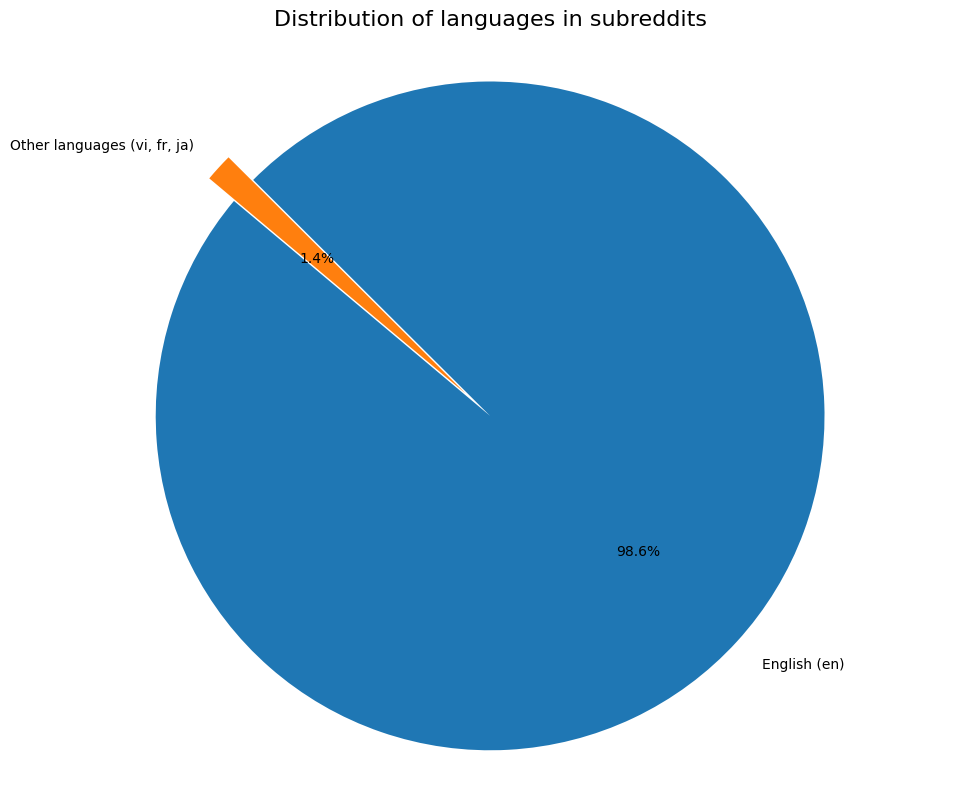


Detailed Distribution table:
language
en        2762
vi           7
de           7
fr           7
ca           4
tl           2
nl           2
ro           2
uknown       1
sk           1
cy           1
sw           1
so           1
it           1
da           1
Name: count, dtype: int64


In [80]:
# Make sure the results are reproducible
DetectorFactory.seed = 0

lang_counts = reddit_df['language'].value_counts()

# Separate subreddits with english apart from the others
en_counts = lang_counts.get('en', 0)
other_counts = lang_counts.sum() - en_counts
# Create a new series to draw chart
lang_plot_data = pd.Series({
    "English (en)": en_counts,
    "Other languages (vi, fr, ja)": other_counts
})

# Draw a pie chart
plt.figure(figsize = (10, 8))
# colors = ['']
plt.pie(
    lang_plot_data,
    labels=lang_plot_data.index,
    autopct= "%1.1f%%", # show percentage
    startangle=140,
    explode=(0, 0.1),  # Create small spaces between slices for easy visibility
)
plt.title("Distribution of languages in subreddits", fontsize=16, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.savefig("language_distribution_chart.png")
plt.show()

print("\nDetailed Distribution table:")
print(lang_counts)

In [81]:
print(f"Subreddits contains Vietnamese has {reddit_vn.shape[0]} rows and {reddit_vn.shape[1]} columns")
print(reddit_vn['full_text']) # Take a peek at these subreddits

Subreddits contains Vietnamese has 7 rows and 10 columns
8                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               PUERTO RICO LÃNH THỔ MỸ - DI SẢN KHIẾN THẾ GIỚI NGÃ MŨ VÀ ĐẤU ĐÁ MG Puerto Rico không nổi lên nhờ may mắn. Nó được tôi luyện qua 500 năm va chạm giữa Tây Ban Nha, Mỹ và bản sắ

We can see that even when the users are diversied, **they still prioritize using English to navigate through the procecss of settling down or receiving helps from international friends**.
=> Therfore, although we plan to use `underthesea` to extract insights from Vietnamese community, we don't have enough data to utilize this package. Hence, we'll translate these posts into English and combine with english dataset

- Since the beginning of March/2026, there has been some changes in Immigration Policies and new plan of increasing the number of immigrants receiving PR, I expected more and more subreddits will appear in Vietnamese, however, for now, since the English subreddits still accounts for more than 95% of the total dataset, I will translate the data in Vietnamese into English for better analyzing sentiments later.

In [82]:
from langdetect.detector_factory import detect_langs
from deep_translator import GoogleTranslator
# Since there's a post that contains both English & Vietnamese, we'll write a function to deal with bilingual
def translated_mix_text(text):
  if pd.isna(text) or text.strip() == "":
    return ""
  sentences = text.split(".")
  translated_sentences = []

  translator = GoogleTranslator(source="auto", target='en')
  for sent in sentences:
    sent = sent.strip()
    if len(sent) < 3: continue

    try:
      lang = detect(sent)
      if lang== "vi": # if the sentence is in Vietnamese => translate
        translated_sentences.append(translator.translate(sent))
      else: # is the sentence is in English => keep
        translated_sentences.append(sent)

    except: # If unable to detect any language, keep the same
        translated_sentences.append(sent)
    return ". ".join(translated_sentences)

In [83]:
reddit_vn['final_en_text'] = reddit_vn['full_text'].apply(translated_mix_text)
reddit_vn['final_en_text']

,final_en_text
8,PUERTO RICO AMERICAN TERRITORY - A LEGACY THAT MAKES THE WORLD HEART AND FIGHT MG Puerto Rico did not emerge by luck
10,Converter National Language → National Language Tan Tu (QATT)
62,"My Vietnamese girlfriend is constantly called by her sister during our dates — is this normal? Hi everyone, I’m a foreign Asian dating a kind Vietnamese single mom"
84,"Which foreign language should be learned that is useful &amp; good career opportunities? Hello everyone, \nI would like to ask for your opinion on learning another language, from the perspective of **practical usefulness and career opportunities**"
91,Final year student
125,Is a 3-storey townhouse real? I'm poor so I'm serious
177,"Sh160 has no battery. Brothers and sisters who have ridden a 2024 sh160 and motorbike repairmen, let me ask if my sh160 suddenly runs out of battery every once in a month or two."


In [84]:
reddit_en['final_en_text'] = reddit_en['full_text']
# Combine the 2 datasets together
cols_to_keep = ['final_en_text', 'language', 'subreddit', 'created_utc', 'score']
reddit_master = pd.concat([reddit_en, reddit_vn], axis = 0).reset_index(drop=True)
reddit_master = reddit_master[cols_to_keep]
reddit_master.shape

(2769, 5)

In [85]:
print(f"There's a total of {len(reddit_master)} posts ready to analyze!")

There's a total of 2769 posts ready to analyze!


In [86]:
# Save this new processed dataframe
reddit_master.to_csv("reddit_master.csv", index=False)

### English:
Use `Spacy` for lowercase, remove stopwords and Lemmatization all at one.
We don't want to set everything in lowercase first since there might be some "misunderstanding" happening (e.g. python and Python - programming language). Besides, remove punctuation first will affect Spacy ability to parse dependency. For numbers, spacy has IS_DIGIT which will help remove them

In [87]:
from collections import Counter
# 1. Load model
nlp = spacy.load("en_core_web_sm")
# Define function to process the text
def get_keywords(text):
    doc = nlp(text[:10000])

    # Get PROPN and NOUN
    keywords = [
        token.lemma_.lower() for token in doc # Lemmatization
        if (token.pos_ in ['PROPN', 'NOUN'])
        and not token.is_stop # Remove stopwords
        and not token.is_punct # Remove punctuations
    ]
    return keywords

print ("Extrapolating keywords (might take roughly 1-2 minutes for 2700 texts)...")

Extrapolating keywords (might take roughly 1-2 minutes for 2700 texts)...



Top 20 keywords:
        Keyword  Count
0           job   1834
1          year   1342
2          time   1082
3        people    827
4    experience    801
5          work    787
6       company    690
7           day    687
8        canada    676
9         month    653
10         role    606
11     position    518
12         lmia    508
13      program    471
14       worker    431
15        thing    425
16         week    412
17  application    390
18       advice    387
19       school    333


/tmp/ipykernel_280/117117369.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




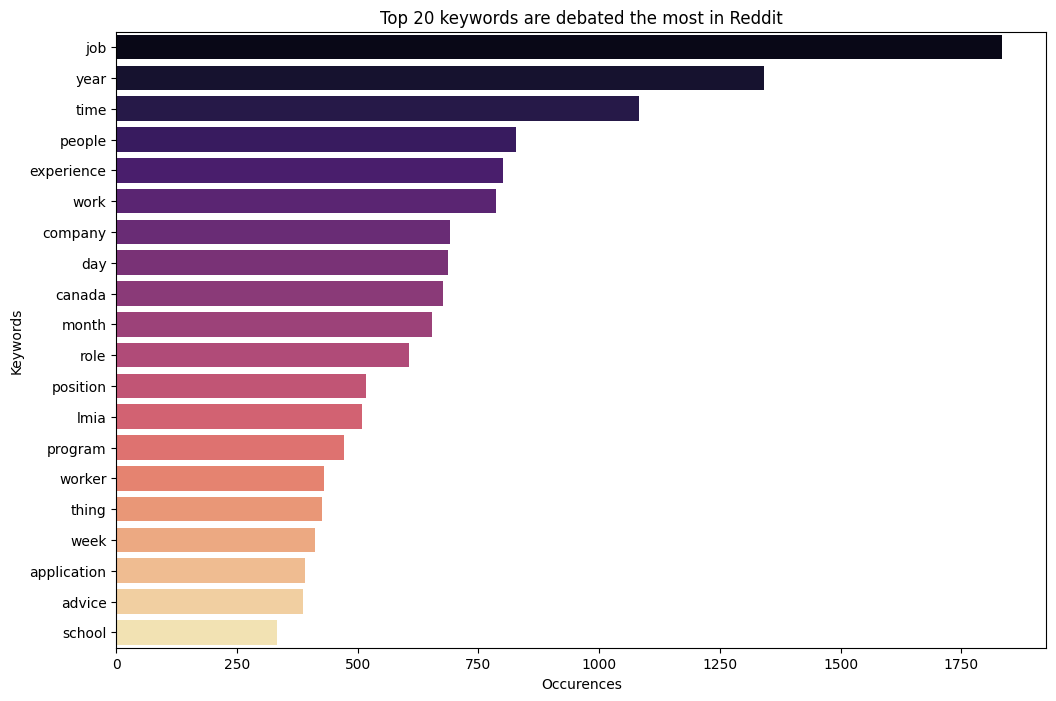

In [88]:
# Apply it to the reddit_en
all_keywords = []
for text in reddit_master['final_en_text']:
    all_keywords.extend(get_keywords(text))

# Get top 20 keywords
top_keywords = Counter(all_keywords).most_common(20)

# Create dataframe to plot the chart
reddit_top_20 = pd.DataFrame(top_keywords, columns = ['Keyword', 'Count'])
print("\nTop 20 keywords:")
print(reddit_top_20)

plt.figure(figsize = (12, 8))
sns.barplot(data = reddit_top_20, x="Count", y="Keyword", palette="magma")
plt.title("Top 20 keywords are debated the most in Reddit")
plt.xlabel("Occurences")
plt.ylabel("Keywords")
plt.savefig('top_20_keywords.png')
plt.show()

From the chart, we can see a few things:
- Top 20 keywords are mostly about **work** (e.g. work, job, experience, position, role, worker, lmia (Labour Market Impact Assessment - very import for immigrants), others words that don't tell much about the topic (e.g. month, day, canada, thing)
- We can see that the immigrants are really concerned about whether they will get LMIA in order to be able to stay in Canada legally for living and working purpose
- If the frequency of LMIA occur with negative words (e.g. scam, fake, pay) increases, it's something that we need to take into account of.

- We can use `Phrase Matching`  to group the similar definitions of immigration/work in Canada:


If we follow the steps above, we will have a list that is, honestly, incomprehensible, we'll use bigrams to take care of this problem (try to match the words in pair - LMIA support, LMIA scam - in order for the sentence to make more sense)

In [89]:
# Clean some more "Reddit trash" after a few trials with wordcloud
cleaned_words = [
    word for word in all_keywords if word.isalpha() # Remove !, ?, 123, &
    and len(word) > 2 # Keep words whose len > 2 (remove "i", "am")
    and word not in ['amp', 'http', 'https', 'reddit', 'post', "people", "day",
                     'get', 'know', 'think', 'want', "year", "time",
                     "thing", "way", "month", "hour", "now", "will"
                     "one", "even", "well"] # Common Reddit trashs
]

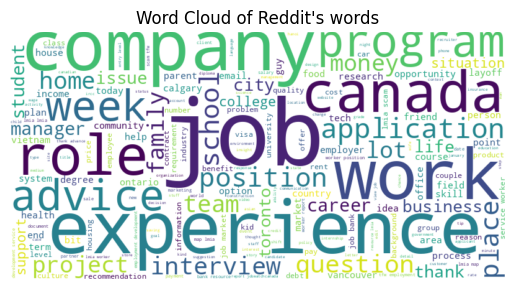

In [90]:
#drawing wordcloud to see what the users' are paying attention to
from numpy.random import random_integers
from wordcloud import WordCloud

def plot_wordcloud(words):
    wordcloud = WordCloud(width=800, height=400, random_state=1, background_color="white")
    wordcloud.generate(" ".join(words))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Reddit's words")
    plt.savefig("foo.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_wordcloud(cleaned_words)

In [91]:
print(f"There are {len(cleaned_words)} words found!")

There are 87880 words found!


In [92]:
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder
# Instantiate the Bigrams measures
bigram_measures = BigramAssocMeasures()

# Create a finder
finder = BigramCollocationFinder.from_words(cleaned_words)

# Only keep the words appearing > 3 times to remove trash
finder.apply_freq_filter(3)

# Filter: only keeps the words that have "lmia"
lmia_filter = lambda w1, w2: "lmia" not in (w1.lower(), w2.lower())
finder.apply_ngram_filter(lmia_filter)

# 3. Tot 10 most popular "lmia terms"
top_lmia_phrases = finder.nbest(bigram_measures.pmi, 10)
print("Top 10 most meaningful terms related to LMIA")
for phrase in top_lmia_phrases:
  print(f"{phrase[0]} {phrase[1]}")


Top 10 most meaningful terms related to LMIA
lmia map
map lmia
lmia scam
resource lmia
lmia justification
resources lmia
mechanic lmia
cook lmia
lmia approval
lmia guideline


In [93]:
lmia_bigram_frequencies = {(" ".join(phrase)): 0 for phrase in top_lmia_phrases}

# Iterate through each text in the "final_en_text" column
for text in reddit_master['final_en_text']:
    if pd.isna(text):
        continue

    text_lower = text.lower() # Convert to lowercase for case-insensitive matching
    for bigram_tuple in top_lmia_phrases:
        bigram_str = " ".join(bigram_tuple) # Convert tuple ('lmia', 'map') to string lmia map
        if bigram_str in text_lower:
            lmia_bigram_frequencies[bigram_str] +=1 # Increment count


print("LMIA Bigram Frequencies:")
for phrases, count in lmia_bigram_frequencies.items():
    print(f"{phrase}: {count}")


# Convert dictionary to dataframe for plotting
lmia_frequencies_df = pd.DataFrame(list(lmia_bigram_frequencies.items()), columns=['Bigram', 'Frequency'])

# Sort
lmia_frequencies_df = lmia_frequencies_df.sort_values(by="Frequency", ascending=False)
print("LMIA Bigrams Frequencies")
print(lmia_bigram_frequencies)

LMIA Bigram Frequencies:
('lmia', 'guideline'): 96
('lmia', 'guideline'): 0
('lmia', 'guideline'): 6
('lmia', 'guideline'): 0
('lmia', 'guideline'): 5
('lmia', 'guideline'): 0
('lmia', 'guideline'): 0
('lmia', 'guideline'): 0
('lmia', 'guideline'): 9
('lmia', 'guideline'): 3
LMIA Bigrams Frequencies
{'lmia map': 96, 'map lmia': 0, 'lmia scam': 6, 'resource lmia': 0, 'lmia justification': 5, 'resources lmia': 0, 'mechanic lmia': 0, 'cook lmia': 0, 'lmia approval': 9, 'lmia guideline': 3}


In [94]:
import plotly.express as px
# Filter out bigrams with zero frequency for treemap to avoid ZeroDivisionError
filtered_lmia_frequencies_df = lmia_frequencies_df[lmia_frequencies_df['Frequency'] > 0]

# Check if there's any data left after filtering
if not filtered_lmia_frequencies_df.empty:
    fig = px.treemap(filtered_lmia_frequencies_df, path=['Bigram'], values='Frequency',
                     title='Top LMIA-Related Bigrams (Frequency > 0)',
                     color='Frequency', color_continuous_scale='Viridis')
    fig.show()
else:
    print("No LMIA-related bigrams with frequency > 0 to display in the treemap.")

#### Post containing cities

In [95]:
## Lists of big cities in Canada
cities = ['Toronto', 'Vancouver', 'Montreal', 'Calgary', 'Edmonton', 'Ottawa', 'Winnipeg',
          'Quebec City', 'Hamilton', 'Kitchener', 'London', 'Victoria', 'Halifax',
          'Brossard', 'Brampton', 'Missisauga']

def find_cities(text):
  if pd.isna(text):
    return "Unknown"
  text_lower = text.lower()
  for city in cities:
    if city.lower() in text_lower:
      return city
  return "Not Mentioned"

reddit_master['city_mentioned']= reddit_master['final_en_text'].apply(find_cities)

<function matplotlib.pyplot.show(close=None, block=None)>

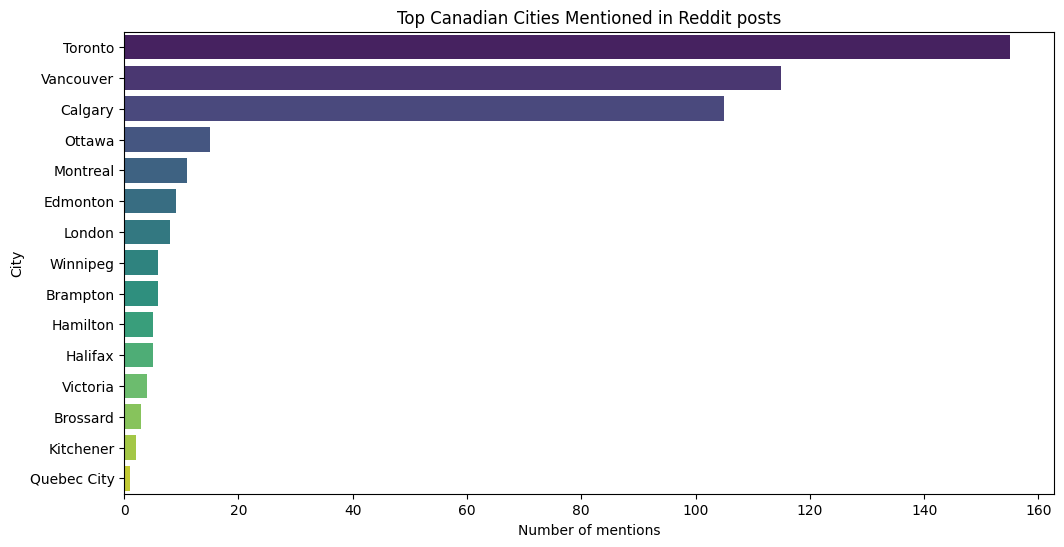

In [96]:
# Remove the posts that don't contain cities
city_counts = reddit_master[reddit_master['city_mentioned'] != 'Not Mentioned']['city_mentioned'].value_counts()

plt.figure(figsize= (12,6))
sns.barplot(x =city_counts.values, y = city_counts.index, palette ='viridis', hue=city_counts.index)
plt.title("Top Canadian Cities Mentioned in Reddit posts")
plt.xlabel('Number of mentions')
plt.ylabel("City")
plt.savefig("Top Canadian Cities Mentioned in Subreddit Posts!")
plt.show

**Time Series Line chart (post Volume/Time)**: Theo dõi số lượng bài đăng theo tuần/tháng. Nếu có 1 đợt sóng bài đăng đột ngột, có thể do 1 chính sách mới vừa ra đời.

In [97]:
# Define a dictionary of keywords related to each of the professions
professions_keywords = {
    'IT/Tech': ['it', 'tech', 'software', 'developer', 'engineer', 'data scientist', 'programmer', 'cybersecurity', 'ai', 'devops', 'web development', 'frontend', 'backend', 'fullstack'],
    'Marketing': ['marketing', 'digital marketing', 'seo', 'sem', 'social media', 'content creator', 'advertising', 'brand', 'campaign'],
    'Cook/Chef': ['cook', 'chef', 'kitchen', 'restaurant', 'food service', 'hospitality'],
    'Healthcare': ['nurse', 'doctor', 'physician', 'healthcare', 'medical', 'hospital', 'caregiver', 'pharmacist'],
    'Trades': ['carpenter', 'electrician', 'plumber', 'welder', 'mechanic', 'construction'],
    'Admin/Office': ['admin', 'administrative', 'assistant', 'office manager', 'receptionist'],
    'Retail': ['retail', 'sales associate', 'cashier', 'store manager'],
    'Logistics': ['driver', 'logistics', 'warehouse', 'supply chain', 'trucker'],
    'Education': ['teacher', 'educator', 'professor', 'school', 'tutor'] }

# Initalize a dictionary to store profession counts
profession_counts = {profession: 0 for profession in professions_keywords.keys()}

for text in reddit_master['final_en_text']:
    if pd.isna(text):
        continue
    text_lower = text.lower()

    for profession, keywords in professions_keywords.items():
        for keyword in keywords:
            if keyword in text_lower:
                profession_counts[profession] +=1
                break # only count once per profession per post, some post might contains more keyword

# Convert to Dataframe for plotting
profession_df = pd.DataFrame(profession_counts.items(), columns=["Profession", "Count"])
# Sort for better visualization
profession_df = profession_df.sort_values(by="Count", ascending=True)

print("Profession Mentions:")
print(profession_df)


Profession Mentions:
     Profession  Count
6        Retail     43
7     Logistics     71
4        Trades     74
5  Admin/Office     87
2     Cook/Chef    121
3    Healthcare    157
1     Marketing    165
8     Education    232
0       IT/Tech   2373


In [98]:
fig= px.bar(profession_df,
            x="Count",
            y="Profession",
            orientation='h',
            title="Most Mentioned Occupation in Reddit Discussion",
            labels={"Count": "Number of Mentions", "Profession": "Job Title"},
            color="Count",
            color_continuous_scale="Viridis",
            text="Count")
fig.show()

## Sentimental Analysis ML model!
- Purpose: understand the public's emotions based on real-time trends that are expressed through words in Reddits

### a. Initial Sentiment EDA
- Use `TextBlob` library (for English) to see general attitude (negative or positive) before diving deeper into more complex models
- we can see **Polarity** (-1 -> 1) and **Subjectivity** (0 -> 1) - the higher the number, the more objective it's, the lower, the more truth it bears

In [99]:
from typing import Text
from textblob import TextBlob
def get_sentiment_score(text):
  return TextBlob(text).sentiment.polarity

# create a collumn named "sentiment_score" for reddit_en
reddit_master['sentiment_score'] = reddit_master['final_en_text'].apply(get_sentiment_score)

# Function to compare emotions between keywords
def analyze_keyword_sentiment(keyword, dataframe):
  # Filter text with keywords, either upper or lowercase
  relevant_posts = dataframe[dataframe['final_en_text'].str.contains(keyword, case=False)]
  avg_score = relevant_posts['sentiment_score'].mean()
  count = len(relevant_posts)
  return avg_score, count

In [101]:
# Analyse users' sentiments in terms of immigration-related topics

immigration_keywords = [
    'immigrant', 'immigration', 'visa', 'residency', 'citizenship',
    'permanent resident', 'refugee', 'asylum', 'deportation', 'border',
    'migrant', 'migration', 'settlement', 'integration', 'sponsor',
    'lmia', 'express entry', 'pnp', 'study permit', 'work permit',
    'family reunification', 'undocumented', 'legal status', 'pathway'
]

print("Immigration Keywords:")
for keyword in immigration_keywords:
    print(f"- {keyword}")

# Test with immigrations words
keywords_test = immigration_keywords
results = []
for k in keywords_test:
  score, count = analyze_keyword_sentiment(k, reddit_master)
  results.append({"Keyword": k, "Avg Sentiment": score, "Post count": count})

df_sentiment = pd.DataFrame(results)
print(df_sentiment)

Immigration Keywords:
- immigrant
- immigration
- visa
- residency
- citizenship
- permanent resident
- refugee
- asylum
- deportation
- border
- migrant
- migration
- settlement
- integration
- sponsor
- lmia
- express entry
- pnp
- study permit
- work permit
- family reunification
- undocumented
- legal status
- pathway
                 Keyword  Avg Sentiment  Post count
0              immigrant       0.066731          36
1            immigration       0.084641          64
2                   visa       0.087837          80
3              residency       0.091215          13
4            citizenship       0.063999          38
5     permanent resident       0.070316          13
6                refugee       0.084984          12
7                 asylum       0.105277           8
8            deportation       0.255159           2
9                 border       0.071121          11
10               migrant       0.070459          38
11             migration       0.082479          68


In [102]:
fig= px.bar(df_sentiment,
            x="Keyword",
            y="Avg Sentiment",
            orientation='v',
            title="Comparing emotions regarding immigration matters!",
            labels={"Keyword": "", "Avg Sentiment": "How positive/negative"},
            color="Keyword",
            color_continuous_scale="Viridis",
            text="Keyword")
fig.show()

From this chart, we can see that there's a clear polarity in the immigrants' minds.
- **Higher sentiment**: terms like "deportation" suprisingly has a higher average positive sentiment but it post counts is pretty low (only 2), so the sentiment might not be a highly representative of a broader situation
- When it comes to LMIA, users usually ask questions such as (How to..., I need help with..., Can someone explain...) and they usually include words like "please, thanks" that inadvertently increase the score a bit (0.074). However, this topic is the most stressful and concerning with the immigrants since it's heavily tied to the chance of being able to settle down and working in Canada.
- **Low sentiment/Neutral**: "Settlement" has a slightly negative average sentiment (-0.047) but there're not a lot posts related to it (only 2). Other terms are "immigrants", "citizenship", "permanent resident" also hover around low positive or neutral sentiment

In [110]:
# Do the same thing with analyzing users' sentiments towards SCAM topic
scam_keywords = [
    'scam', 'fraud', 'fake', 'deception', 'trick', 'con', 'bogus', 'illegal',
    'unauthorized', 'pyramid scheme', 'get rich quick',
    'identity theft', 'personal information', 'easy money',
    'whatsapp', 'telegram', 'dm me', 'contact me'
]

# print("Scam Keywords:")
# for keyword in scam_keywords:
#     print(f"- {keyword}")

# Apply Textblob
keywords_test_2 = scam_keywords
results_2 = []
for k in keywords_test_2:
  score, count = analyze_keyword_sentiment(k, reddit_master)
  results_2.append({"Keyword": k, "Avg Sentiment": score, "Post count": count})

df_sentiment_scam = pd.DataFrame(results_2)
print(df_sentiment_scam)

                 Keyword  Avg Sentiment  Post count
0                   scam       0.087093         139
1                  fraud       0.043783          23
2                   fake       0.061609          20
3              deception       0.023011           1
4                  trick       0.067882           8
5                    con       0.085325         996
6                  bogus       0.072355           1
7                illegal      -0.094508          12
8           unauthorized       0.016176           1
9         pyramid scheme       0.036253           1
10        get rich quick       0.025766           1
11        identity theft       0.026794           2
12  personal information       0.101424           3
13            easy money       0.022222           1
14              whatsapp       0.109326           4
15              telegram       0.092157           1
16                 dm me       0.181689          11
17            contact me       0.072318           3


In [111]:
# draw a plot for this
fig= px.bar(df_sentiment_scam,
            x="Keyword",
            y="Avg Sentiment",
            orientation='v',
            title="Comparing emotions regarding SCAM-related matters!",
            labels={"Keyword": "", "Avg Sentiment": "How positive/negative"},
            color="Keyword",
            color_continuous_scale="Viridis",
            text="Keyword")
fig.show()

In [112]:
# Get some examples about LMIA
scam_keywords = ['scam', 'fake', 'loophole', 'fraud', 'illegal', 'pay']
lm_scam_pattern = "|".join(scam_keywords)
lm_scam_posts = reddit_master[reddit_master['final_en_text'].str.contains('lmia', case=False) &
                  reddit_master['final_en_text'].str.contains(lm_scam_pattern, case=False)
]

print(f"Found {len(lm_scam_posts)} subreddits that might related to LMIA Scams")

Found 113 subreddits that might related to LMIA Scams


In [113]:
print("\n-- Some examples about LMIA scams for recruiters--")
for i, row in lm_scam_posts.head(3).iterrows():
  print(f"Subreddit: {row['subreddit']}")
  print(f"Title: {row['final_en_text']}")
  print(f"{TextBlob(row['final_en_text']).sentiment.polarity:.2f}")


-- Some examples about LMIA scams for recruiters--
Subreddit: CanadaJobs
Title: Is entry -level job market in Canada officially dead? 
I honestly don’t know what to do anymore. I have tried to apply on indeed , Craigslist. I’m a fresh grad and it feels like I’m fighting for my life just to get a call back for a minimum wage job, let alone a career in my field. 
Is it just me, or is the "economic circle" in this country totally broken?
• The TFW / LMIA Loophole: It feels like every "entry-level" posting is just a ghost ad so companies can prove they "tried" to hire a Canadian before they go get an LMIA. I’ve seen posts for basic roles that get filled by TFWs who are basically stuck at that job because of their permit.
• The "Experience" Paradox: Since when does a junior role require 3+ years of experience? I’m seeing people with Master’s degrees applying for data entry just to pay rent, which pushes the rest of us even further down.
• The Spending Leak: It’s frustrating to see so many 

VADER (Valence Aware Dictionary)
- With VADER, every one of the words in the vocabulary is apraised with respect to whether it's positive or negative, how +ve or -ve (according to [Analytics](https://www.analyticsvidhya.com/blog/2021/06/vader-for-sentiment-analysis/#h-what-is-vader-sentiment-analysis)

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")

# Function to print sentiments of the the sentences
def sentiment_scores(sentence):
  # Create a SentimentIntensityAnalyzer object
  sid_obj = SentimentIntensityAnalyzer()

  # polarity_scores method of SentimentIntensityAnalyzer
  # oject gives a sentiment dictionary which containes pos, neg, neu, and compound score
  sentiment_dict = sid_obj.polarity_scores(sentence)
  print("Overall sentiment dictionary is: ", sentiment_dict)
  print("Sentence was rate as: ", sentiment_dict['neg']*100, "% negative")
  print("Sentence was rate as: ", sentiment_dict['neu']*100, "% neutral")
  print("Sentence was rate as: ", sentiment_dict['pos']*100, "% positive")
  print("Sentence overall rated as", end ="")
  # Decide sentiment as positive, negative and neutral
  if sentiment_dict['compound'] >= 0.05:
    return("Positive")
  elif sentiment_dict['compound'] <= -0.05:
    return("Negative")
  else:
    return("Neutral")

In [ ]:
# Apply the function to our df!
reddit_master['attitude'] = reddit_master['final_en_text'].apply(sentiment_scores)
reddit_master.head(3)

In [ ]:
# Check out the distribution of users' attitudes
reddit_master['attitude'].value_counts()

# Use plotly to plot this finding
fig = px.pie(reddit_master, names='attitude', title="Distribution of users' attitude")
fig.show()
plt.savefig("attitude_distribution.png")

### Things to consider in the future
1.3. Topic Modelling
- LDA
- BERTopic (much better). From this, we'll see
=> Tops popular topic weekly
- Which topic might seems like SCAM?
- Which topic is hot in Canada

## 2. SCAM detection ML model!
- Purpose: check if a post is categoriez as SCAM or not based on learned information

1.   Baseline model
- TF-IDF + Logistic regression
- TF-IDF + Linear SVM
- Naive Bayes
=> Give us a good baseline model
2.   After that, upgrade to strong model
- DistilBERT + fine-tuning
- RoBERTa-base -> very strong for classification
=> these ones can catch deeper scam patterns (tone, phrasing)

### Some keywords Analysis for Scam detectors
Create binary features:
- contains_whatsapp
- contains_telegram
- contains_fee
- contains_cash_job
- contains_no_company_name
- contains_visa_sponsorship
These are features for the model.



1.2. Extract structured signals from posts
**Generate additional features** such as:
- Location extractions (Canada cities -> NEX or Regex)
- Salary mentions extraction ($xx/hr)
- Contract type (full-time, part-time, internship...)
- Recruiters keywords ("DM me", "message me on Whatsapp", "telegram", "upfront fee"
=> these features might be critical to **detect scam**

Create a CSV for Labelling
Columns:
- post_id
- title
- body
- subreddit
- scam_label (initially empty)
Export it to simple Google Sheet

2.1. Label ~300-500 posts (cannot train without labels)
- scam = 1
- legit = 0

Signs for scam can be:
- WhatsApp contact
- Telegram link
- Upfront payment
- Too-good-to-be-true salary
- No company name
- Links to unfamiliar domains
- Referral fee
- Duplicate posts across subreddits
- Poor English + inconsistent formatting

2.3. Evaluation
- Precision: most important - we don't want to flag thea legit posts
- Recall
- ROC-AUC

## 3. Build interactive dashboard
3.1. Scraper schedule
- Runs automatically every monday
- Use GitHub Actions or Python Cron
- Scrape every subreddit
- Save to S3 / local/ SQLite/ PostgreSQL

3.2. Dashboard features.

Use Streamlit or Dash. Should have
- Live subreddits statistics.
- Job trends by city
- Salary mentions trend
- Keyword monitoring ("visa sponsor", "LMIA", "cash job")
- Scam detector, (highlight suspicious posts)
- Filter by time, location, subreddit